# PTI-Clima Notebooks  <img src="https://www.r-project.org/logo/Rlogo.png" alt="Description" width="60" height="40">

***

> Este cuaderno o notebook muestra LO QUE MUESTRE EL NOTEBOOK utilizando los conjuntos de datos de la PTI-Clima que se incluyen en el [almacén de datos](https://pti.climate.ifca.es/data). Este trabajo está licenciado bajo una [Licencia Creative Commons Atribución 4.0 Internacional](http://creativecommons.org/licenses/by/4.0).
>
> ![Licencia de Creative Commons](https://i.creativecommons.org/l/by/4.0/88x31.png)


## Guía para el uso del dataset: ERA5-Land

**M. Fuente-González** (Instituto de Física de Cantabria, CSIC-Universidad de Cantabria, Santander, Spain).

**¡Bienvenidos al cuaderno "Guía para el uso del dataset: ERA5-Land" de la Plataforma Virtual de Cálculo de la PTI-Clima!**  
Esta guía tiene como objetivo ayudarte a entender y cargar el dataset ERA5-Land, de manera que puedas sacar el máximo provecho de estos datos disponibles en el [**Almacén de Datos de la PTI-Clima**](https://pti.climate.ifca.es/data). A través de esta plataforma, podrás realizar investigaciones y **análisis climáticos de relevancia**, ya que ofrece **acceso transparente a una amplia gama de materiales y datos** subyacentes a los **servicios climáticos desarrollados en la PTI-Clima**, fomentando su **reutilización** y posibilitando la **reproducibilidad** de los productos generados.

En concreto, esta guía pretende ayudarte a entender como cargar un dataset para usar las diferentes variables en diferentes tipos de estudios, ya sea el cálculo de índices, análisis climáticos, etc. El objetivo principal es que comprendas de forma general la carga de datos y que puedas llevarlo a cabo en tus propias investigaciones. Se trata de un cuaderno que contiene conceptos básicos para poder entender y reproducir otros de manera más autodidácta. De esta manera vamos a **guiarte** a través de los pasos fundamentales para trabajar de manera efectiva con los datos este tipo de daatasets.

Tras la carga de datos, habrá bloques de visualizaciones, permitiendo familiarizarte con este tipo de análisis de resultados y permitiendote aprender diferentes tipos de representacionse. Para todo ello, se utilizará el **framework *climate4R***, un conjunto de librerías de R para la carga, post-procesamiento y análisis de datos climáticos. 


<img src="https://raw.githubusercontent.com/SantanderMetGroup/climate4R/refs/heads/devel/man/figures/climate4R_logo.svg" alt="Description" width="60" height="40">

***climate4R*** ofrece más funcionalidades de las que se ilustran en este notebook, como **funcionalidades de operaciones espaciales y temporales** o como **interpolación, subsetting o intersección espacial**. Además, brinda funcionalidades para la **corrección de sesgo y downscaling** o funciones específicas para el **cálculo de índices**. Consulta [Iturbide et al., 2019](https://www.sciencedirect.com/science/article/pii/S1364815218303049?via%3Dihub) y el repositorio de [github de climate4R](https://github.com/SantanderMetGroup/climate4R) para más información.

### Contenido de este cuaderno
1) Carga de librerías
2) Selección de conjuntos de datos  
3) Carga de datos
4) Análisis básico
   * 4.1. Medias climatológicas
   * 4.2. Percentiles
   * 4.3. Índices
   * 4.4. Precipitación
   * 4.5. Series temporales

Empezamos dando la memoria que queramos a la RAM (la suficiente para poder cargar varios variables)

In [32]:
options(java.parameters = "-Xmx13g")

### 1. Carga de librerías

Cargamos las librerías necesarias, que corresponden a librerías del framework *climate4R* y van a permitir cargar datos, transformarlos, usar índices y visualizarlos.

In [33]:
library(loadeR)
library(transformeR)
library(climate4R.indices)
library(visualizeR)

### 2. Selección de conjuntos de datos  

Leemos el archivo donde se tiene el contenido de todos los datasets y vemos que pinta tiene para decidir que es lo que queremos cargar.

In [34]:
df <- read.csv("../data_inventory.csv")

In [35]:
head(df)

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AEMET-5KM-regular_Iberia_day,observations,opendap,AEMET-5KM-regular,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/AEMET-5KM-regular/Iberia/day/AEMET-5KM-regular_Iberia_day.ncml,../../Harmonization_dictionaries/AEMET-5KM-regular.dic
2,CHELSA-W5E5v1.0_Canarias_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Canarias/day/CHELSA-W5E5v1.0_Canarias_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
3,CHELSA-W5E5v1.0_Iberia_day,observations,opendap,CHELSA-W5E5v1.0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/CHELSA-W5E5v1.0/Iberia/day/CHELSA-W5E5v1.0_Iberia_day.ncml,../../Harmonization_dictionaries/CHELSA-W5E5v1.0.dic
4,PTI-grid-v0_Canarias_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Canarias/day/PTI-grid-v0_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
5,PTI-grid-v0_Iberia_day,observations,opendap,PTI-grid-v0,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v0/Iberia/day/PTI-grid-v0_Iberia_day.ncml,../../Harmonization_dictionaries/PTI-grid-v0.dic
6,PTI-grid-v1_Canarias_day,observations,opendap,PTI-grid-v1,,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/OBSERVATIONS/PTI-grid-v1/Canarias/day/PTI-grid-v1_Canarias_day.ncml,../../Harmonization_dictionaries/PTI-grid-v1.dic


En este caso, vamos a cargar el dataset de ERA5-Land. Como no hemos visto en la celda anterior el dataset que queremos, filtramos las filas que contengan "ERA5". 

In [36]:
df[grep("ERA5", df$source), ]

,dataset,type,access,source,provider,experiment,frequency,endpoint,dictionary
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
119,ERA5-Land_Canarias_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Canarias/day/ERA5-Land_Canarias_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic
120,ERA5-Land_Iberia_day,reanalysis,opendap,ERA5-Land,ecmwf,,day,https://hub.climate4r.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Iberia/day/ERA5-Land_Iberia_day.ncml,../../Harmonization_dictionaries/ERA5-Land.dic


### 3. Carga de datos

##### Trabajamos con observaciones de la Península Ibérica

Se tienen dos datasets que coinciden con con ERA5-Land, uno que corresponde con la Península Ibérica y otro que corresponde con las Islas Canarias. Ambos son datsets de tipo reanalisis, y vamos a cargar el que corresponde con la Península Ibérica, ERA5-Land_Iberia_day.

Primero llamamos al dataset concreto que queremos analizar, apuntando con el sufijo *endpoint*, a la url que queremos referirnos. A continuación, hacemos un inventario para saber que variables tiene el dataset y en que unidades están.

In [37]:
subset.pi <- subset(df, dataset == "ERA5-Land_Iberia_day")
lon.pi <- as.character(subset.pi$endpoint)
obs.pi <- dataInventory(lon.pi)

[2025-09-30 12:53:39.816504] Doing inventory ...

[2025-09-30 12:53:40.001207] Opening dataset...

[2025-09-30 12:53:40.622811] The dataset was successfuly opened

[2025-09-30 12:53:41.077389] Retrieving info for 'sp' (5 vars remaining)

[2025-09-30 12:53:41.126636] Retrieving info for 'tp' (4 vars remaining)

[2025-09-30 12:53:41.173211] Retrieving info for 't2mx' (3 vars remaining)

[2025-09-30 12:53:41.211514] Retrieving info for 'sfcwind' (2 vars remaining)

[2025-09-30 12:53:41.255104] Retrieving info for 't2m' (1 vars remaining)

[2025-09-30 12:53:41.291092] Retrieving info for 't2mn' (0 vars remaining)

[2025-09-30 12:53:41.33448] Done.



In [38]:
str(obs.pi)

List of 6
 $ sp     :List of 7
  ..$ Description: chr "Surface pressure"
  ..$ DataType   : chr "float"
  ..$ Shape      : int [1:3] 26298 101 161
  ..$ Units      : chr "Pa"
  ..$ DataSizeMb : num 1711
  ..$ Version    : logi NA
  ..$ Dimensions :List of 3
  .. ..$ time     :List of 4
  .. .. ..$ Type      : chr "Time"
  .. .. ..$ TimeStep  : chr "1.0 days"
  .. .. ..$ Units     : chr "days since 1950-01-01 00:00:00"
  .. .. ..$ Date_range: chr "1950-01-01T00:00:00Z - 2021-12-31T00:00:00Z"
  .. ..$ latitude :List of 5
  .. .. ..$ Type       : chr "Lat"
  .. .. ..$ Units      : chr "degrees_north"
  .. .. ..$ Values     : num [1:101] 44 43.9 43.8 43.7 43.6 ...
  .. .. ..$ Shape      : int 101
  .. .. ..$ Coordinates: chr "latitude"
  .. ..$ longitude:List of 5
  .. .. ..$ Type       : chr "Lon"
  .. .. ..$ Units      : chr "degrees_east"
  .. .. ..$ Values     : num [1:161] -10 -9.9 -9.8 -9.7 -9.6 ...
  .. .. ..$ Shape      : int 161
  .. .. ..$ Coordinates: chr "longitude"
 $ tp     :

Vamos a cargar la temperatura máxima diaria, que como se puede ver al hacer el inventario, hay que referirse a ella como *"t2mx"*. De todo el posible periodo que se tiene (1950-2021) vamos a cargar una región en específico (correspondiente a la parte norte de la Península Ibérica) y el periodo desde el 2000 al 2010.

In [39]:
tasmax.pi <- loadGridData(dataset = lon.pi,
                           var = "t2mx",
                           lonLim=c(-7.4,-2.7),
                           latLim=c(41.9, 43.9),
                           years=2000:2010)

[2025-09-30 12:53:41.629255] Opening dataset...

[2025-09-30 12:53:42.232181] The dataset was successfuly opened

[2025-09-30 12:53:42.238269] Defining geo-location parameters

[2025-09-30 12:53:42.281145] Defining time selection parameters

[2025-09-30 12:53:42.423748] Retrieving data subset ...

[2025-09-30 12:53:48.485828] Done



Volvemos a llamar a la funcion *str* para ver la pinta que tiene la temperatura máxima, con esto podemos ver la resolución del dataset, unidades (en caso de no habernos fijado antes), etc.

In [40]:
str(tasmax.pi)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "t2mx"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "daily maximum temperature"
  ..- attr(*, "units")= chr "K"
  ..- attr(*, "longname")= chr "t2mx"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:4018, 1:21, 1:48] 281 281 282 280 278 ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:48] -7.4 -7.3 -7.2 -7.1 -7 ...
  ..$ y: num [1:21] 41.9 42 42.1 42.2 42.3 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GMT" "2000-01-03 00:00:00 GMT" "2000-01-04 00:00:00 GMT" ...
  ..$ end  : chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GMT" "2000-01-03 00:00:0

Podemos observar, que este dataset corresponde con la temperatura máxima y en el atributo "units" vemos que está en grados Kelvin. Tiene una resolución de 0.10, es decir de unos 10 km aproximadamente y los datos son diarios. Como se ha elegido un un periodo concreto de tiempo (de 2000 a 2010) y de espacio (latitud de 41.9 a 43.9 y longitud de -7.4 a -2.7), las dimensiones y tamaño corresponden con este subconjunto.

### 4. Análisis

#### 4.1. Media climatológica

Una vez tenemos el dataset cargado, pasamos a la parte de *visualización*. Para ello, una de las opciones es hacer una climatología y representarlo espacialmente. La función *spatialPlot*, permite realizar esta representación y dependiendo de los argumentos que se pasen, puedes modifcar el colorbar, añadir títulos, nombres a los ejes, etc.

Como hemos comentado, las unidades en las que viene la temperatura de este dataset son grados  Kelvin, vamos a convertirlo a grados Celsius antes de comenzar con las medias climátologícas y el análisis en general.

In [41]:
tasmax.pi <- gridArithmetics(tasmax.pi, 273.15, operator = "-")

[2025-09-30 12:53:49.57517] - Computing climatology...

[2025-09-30 12:53:49.656953] - Done.



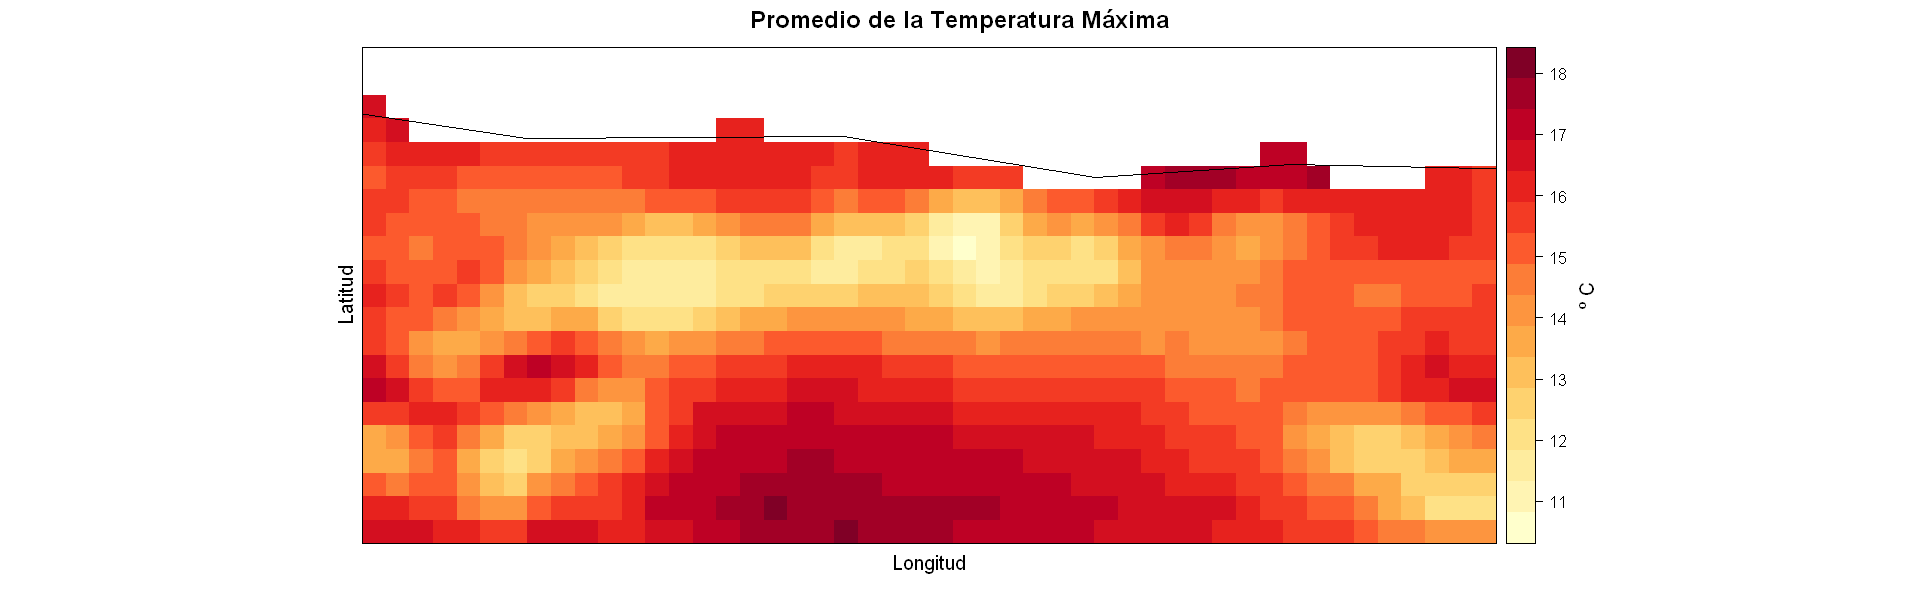

In [42]:
spatialPlot(climatology(tasmax.pi), main="Promedio de la Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
            )

#### 4.2. Percentiles

En vez del promedio, también podemos ver las colas de la distribución, como el percentil 90. Para ello, se le pasa a la función *climatology* dentro del argumento clim.fun lo que queremos que se haga.

In [43]:
p90.tmax <- climatology(tasmax.pi, clim.fun = list(FUN = "quantile", probs=0.90, na.rm=TRUE))

[2025-09-30 12:53:50.026782] - Computing climatology...

[2025-09-30 12:53:50.197783] - Done.



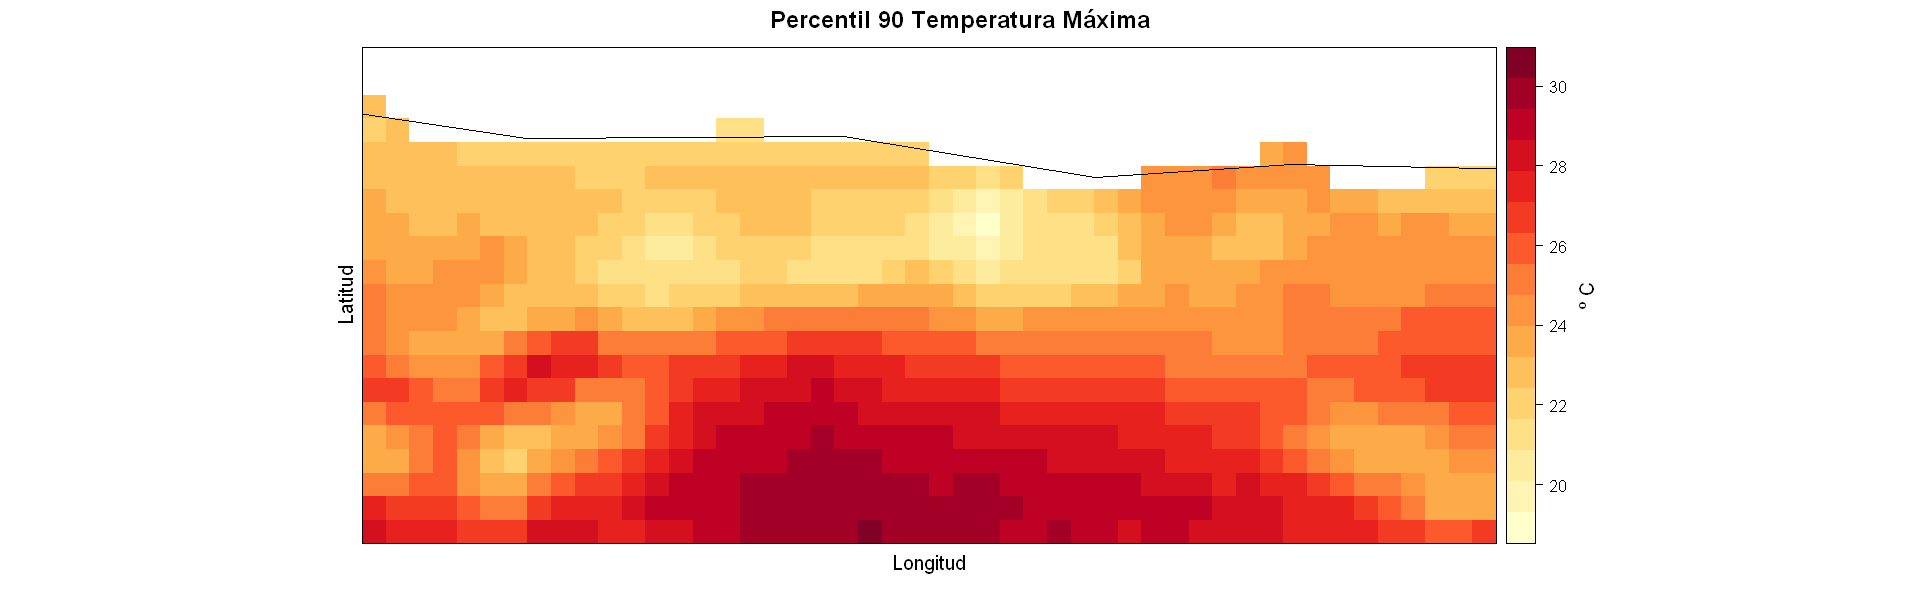

In [44]:
spatialPlot(p90.tmax, main="Percentil 90 Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

O el percentil 10.

In [45]:
p10.tmax <- climatology(tasmax.pi, clim.fun = list(FUN = "quantile", probs=0.10, na.rm=TRUE))

[2025-09-30 12:53:50.46449] - Computing climatology...

[2025-09-30 12:53:50.622469] - Done.



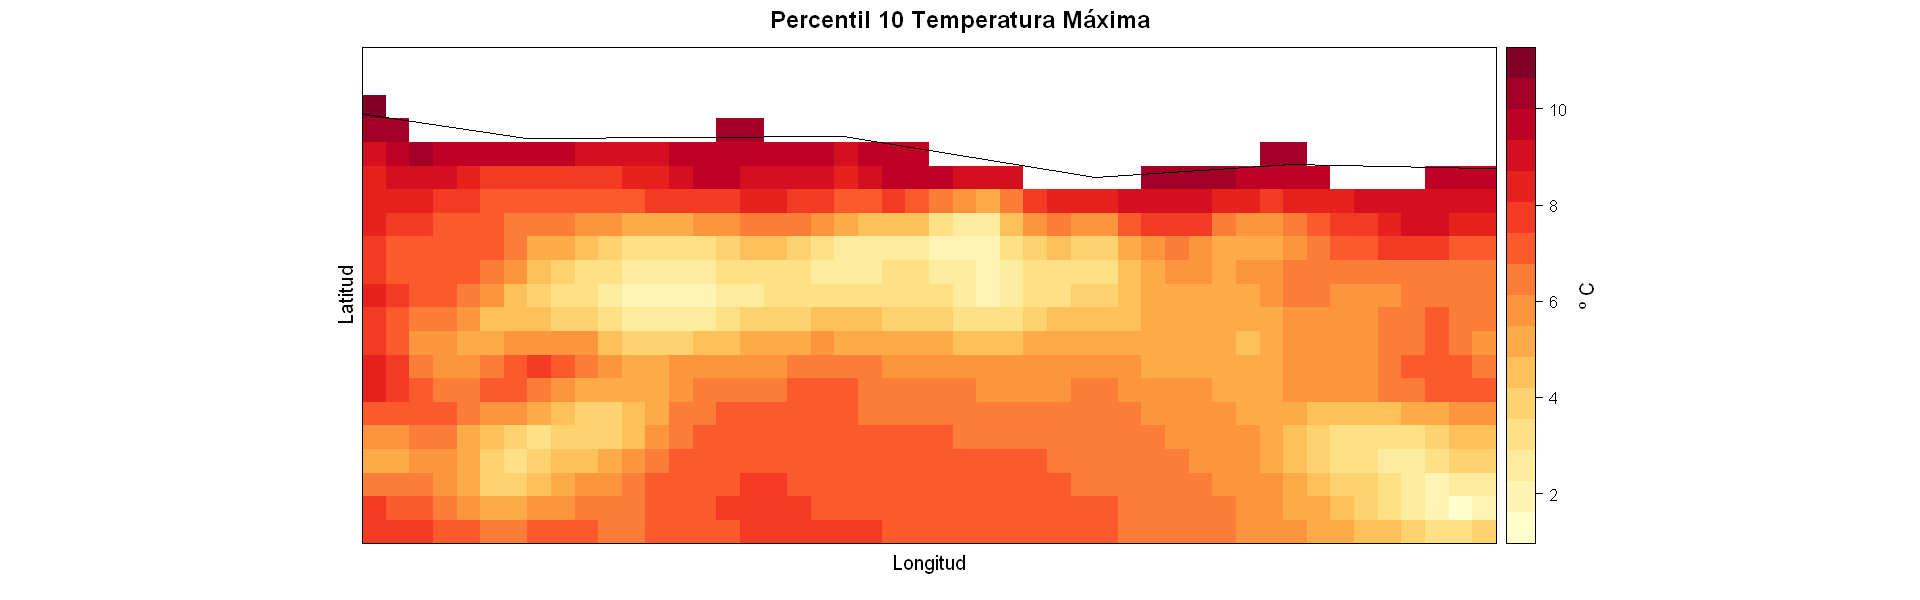

In [46]:
spatialPlot(p10.tmax, main="Percentil 10 Temperatura Máxima", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("º C", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

#### 4.3. Índices

Al igual que parámetros estadísticos, también podemos mirar índices. En este caso, vamos a ver cuántos días del año en cada gridbox se da que la temperatura esté por encima de 35 ºC. Para eso usamos la función *indexGrid* y sumamos los días del periodo con *sum* usando la función *climatology*

In [47]:
idx35 <- indexGrid(tx=tasmax.pi, index.code="TXth", th=35)

[2025-09-30 12:53:51.004653] Calculating TXth ...

[2025-09-30 12:53:51.249482] Done



In [48]:
sum.idx35 <- climatology(idx35, clim.fun = list(FUN = "sum"))

[2025-09-30 12:53:51.276302] - Computing climatology...

[2025-09-30 12:53:51.278465] - Done.



Es necesario, que una vez sumamos los días, pasarle una máscara de tierra. Por eso, primero creamos la máscara y a continuación, con la función *gridArithmetics* la aplicamos.

In [49]:
mask <- climatology(tasmax.pi)
mask$Data[!is.na(mask$Data)] <- 1

[2025-09-30 12:53:51.314107] - Computing climatology...

[2025-09-30 12:53:51.380659] - Done.



In [50]:
idx35.masked <- gridArithmetics(sum.idx35, mask, operator="*")

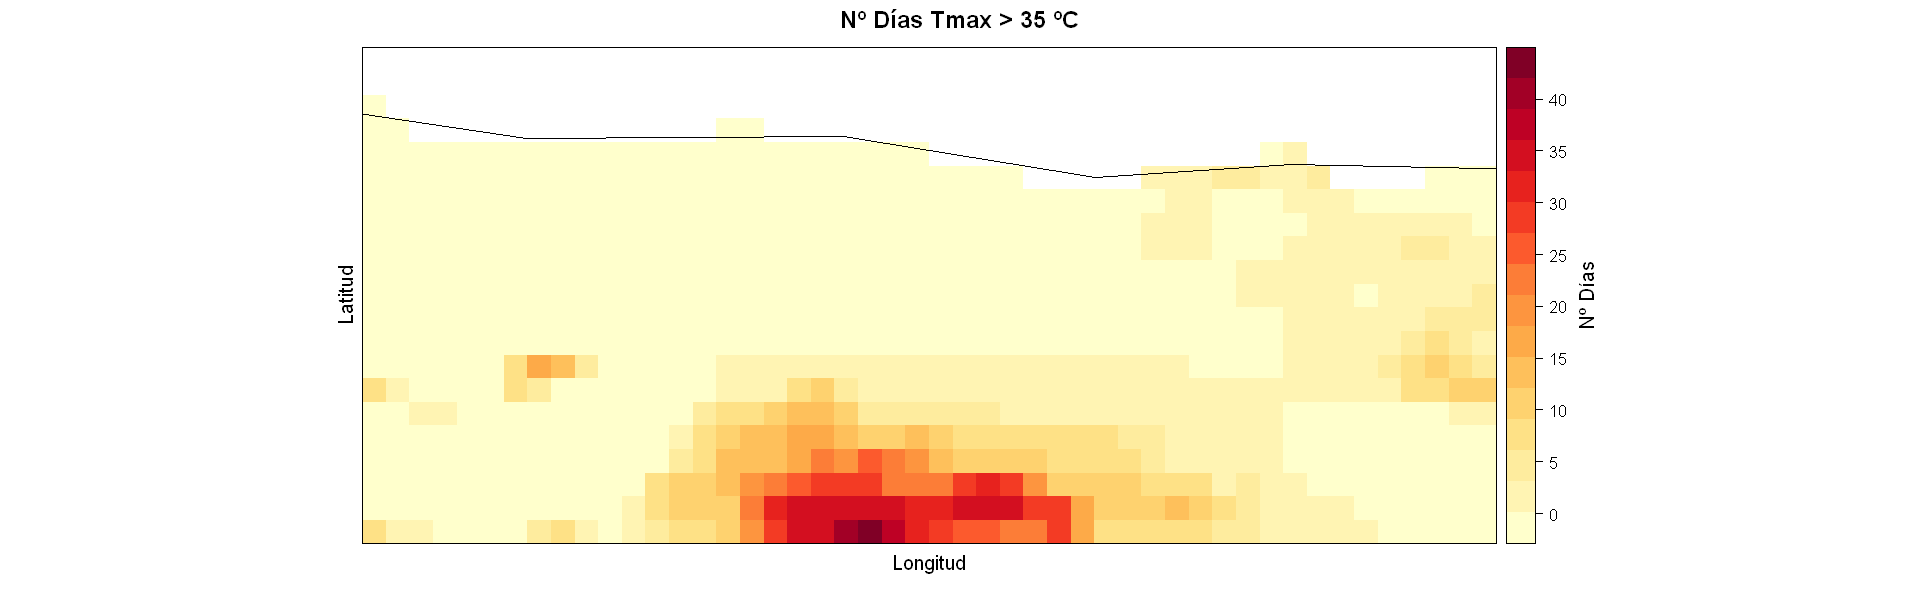

In [51]:
spatialPlot(idx35.masked, main="Nº Días Tmax > 35 ºC", backdrop.theme="coastline", color.theme="YlOrRd", 
            colorkey = list(space = "right",
                            title = list("Nº Días", cex = 1)),
                            xlab = "Longitud",
                            ylab = "Latitud"
                           
            )

#### 4.4. Precipitación

No solo se puede cargar la variable de temperatura máxima. Como hemos visto antes al ver las variables del dataset, también se tienen tiene temperatura mínima, presión en superficie, precipitación, etc. A continuación, cargaremos la precipitación, para ello nos referimos a ella como *"tp"*. Cargamos la misma región y el mismo periodo.

In [52]:
pr.pi <- loadGridData(dataset = lon.pi,
                           var = "tp",
                           lonLim=c(-7.4,-2.7),
                           latLim=c(41.9, 43.9),
                           years=2000:2010)

[2025-09-30 12:53:51.943661] Opening dataset...

[2025-09-30 12:53:52.493165] The dataset was successfuly opened

[2025-09-30 12:53:52.495892] Defining geo-location parameters

[2025-09-30 12:53:52.529015] Defining time selection parameters

[2025-09-30 12:53:52.66766] Retrieving data subset ...

[2025-09-30 12:53:58.245977] Done



In [53]:
str(pr.pi)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tp"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Total precipitation"
  ..- attr(*, "units")= chr "m"
  ..- attr(*, "longname")= chr "tp"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "none"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:4018, 1:21, 1:48] -3.47e-18 1.83e-06 1.10e-05 1.28e-05 8.55e-05 ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:48] -7.4 -7.3 -7.2 -7.1 -7 ...
  ..$ y: num [1:21] 41.9 42 42.1 42.2 42.3 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GMT" "2000-01-03 00:00:00 GMT" "2000-01-04 00:00:00 GMT" ...
  ..$ end  : chr [1:4018] "2000-01-01 00:00:00 GMT" "2000-01-02 00:00:00 GMT" "20

Las unidades de esta variable son m, si se quiere trabajar en mm/diarios, es necesario hacer la correspondiente conversión. Para proceder de forma distinta y ver otras funcionalidades del framework y como tratar el dataset, vamos a hacer una agregación mensual.

In [54]:
pr.pi <- gridArithmetics(pr.pi, 1000, operator = "*")

In [55]:
pr.pi.aggr.m <- aggregateGrid(pr.pi, aggr.m=list(FUN="sum"))

[2025-09-30 12:53:59.122135] Performing monthly aggregation...

[2025-09-30 12:53:59.464364] Done.



Para una visualización espacial, recurrimos de nuevo a la función *spatialPlot*.

[2025-09-30 12:53:59.490271] - Computing climatology...

[2025-09-30 12:53:59.497811] - Done.



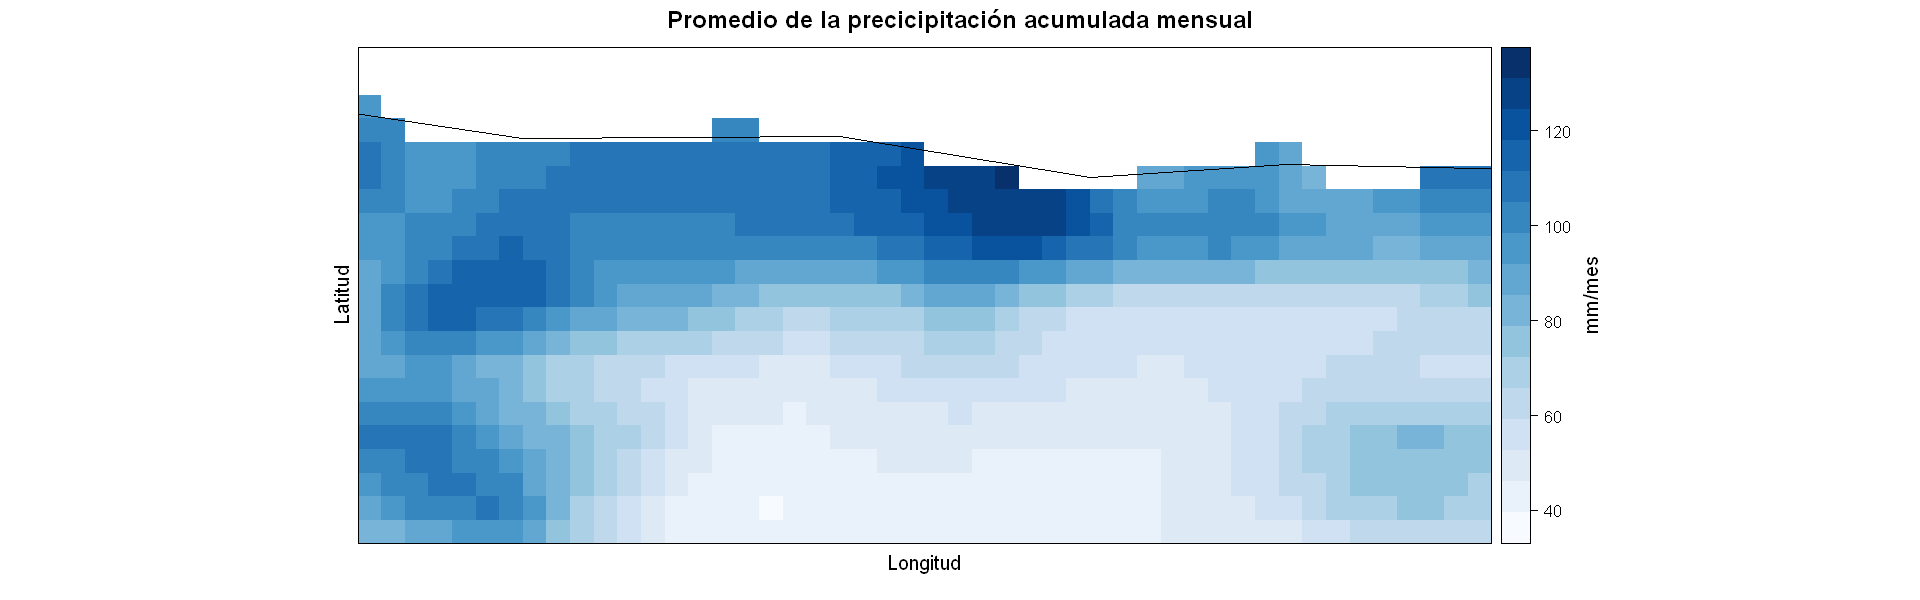

In [56]:
spatialPlot(climatology(pr.pi.aggr.m), main="Promedio de la precicipitación acumulada mensual", backdrop.theme="coastline", color.theme="Blues", 
            colorkey = list(space = "right",
                            title = list("mm/mes", cex = 1)
                           ),
            xlab = "Longitud",
            ylab = "Latitud"
            )

#### 4.5. Series temporales


Elegimos varios puntos de la región de la península cargada. Para ver las diferencias se escoge Burgos, Santander y Oviedo. De esta manera, al usar la función *subsetGrid*, nos quedamos unicamente con la latitud y longitud seleccionadas.

In [57]:
burgos <- subsetGrid(pr.pi.aggr.m, latLim=42.3, lonLim=-3.7)
santander <- subsetGrid(pr.pi.aggr.m, latLim=43.4, lonLim=-3.8)
oviedo <- subsetGrid(pr.pi.aggr.m, latLim=43.3, lonLim=-5.8)

In [58]:
str(pr.pi.aggr.m)

List of 4
 $ Variable:List of 2
  ..$ varName: chr "tp"
  ..$ level  : NULL
  ..- attr(*, "use_dictionary")= logi FALSE
  ..- attr(*, "description")= chr "Total precipitation"
  ..- attr(*, "units")= chr "m"
  ..- attr(*, "longname")= chr "tp"
  ..- attr(*, "daily_agg_cellfun")= chr "none"
  ..- attr(*, "monthly_agg_cellfun")= chr "sum"
  ..- attr(*, "verification_time")= chr "none"
 $ Data    : num [1:132, 1:21, 1:48] 21.6 18.6 30.8 240.1 93.1 ...
  ..- attr(*, "dimensions")= chr [1:3] "time" "lat" "lon"
 $ xyCoords:List of 2
  ..$ x: num [1:48] -7.4 -7.3 -7.2 -7.1 -7 ...
  ..$ y: num [1:21] 41.9 42 42.1 42.2 42.3 ...
  ..- attr(*, "projection")= chr "LatLonProjection"
  ..- attr(*, "resX")= num 0.1
  ..- attr(*, "resY")= num 0.1
 $ Dates   :List of 2
  ..$ start: chr [1:132(1d)] "2000-01-01 00:00:00 GMT" "2000-02-01 00:00:00 GMT" "2000-03-01 00:00:00 GMT" "2000-04-01 00:00:00 GMT" ...
  ..$ end  : chr [1:132(1d)] "2000-01-31 00:00:00 GMT" "2000-02-29 00:00:00 GMT" "2000-03-31 00:00:0

Usando la funcion *temporalGrid* podemos visualizar las series temporales de la precipitación acumulada mensual tanto para los gridboxes seleccionados, como para una media de toda la región cargada.

pad applied on the interval: month

pad applied on the interval: month

pad applied on the interval: month

pad applied on the interval: month



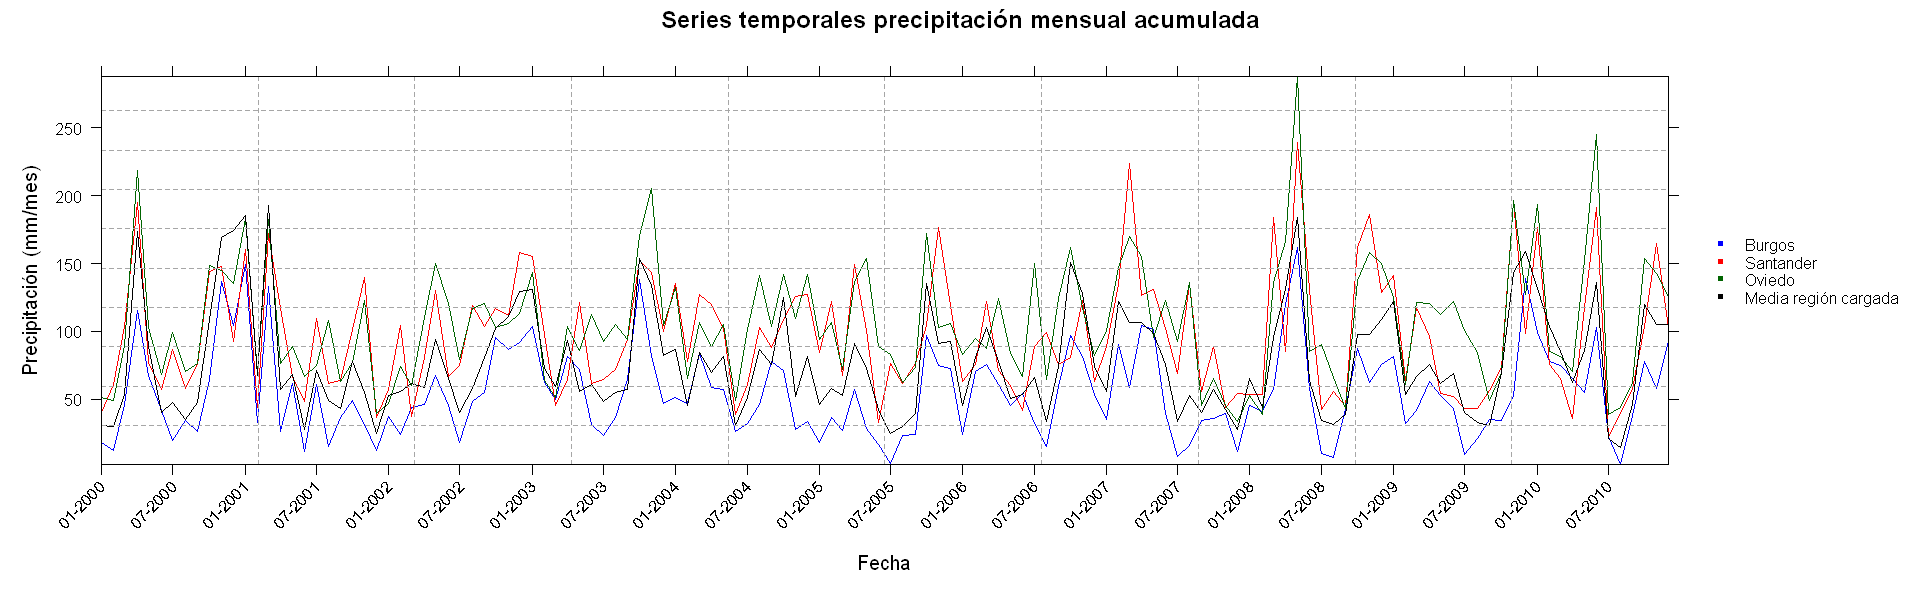

In [59]:
options(repr.plot.width = 16, repr.plot.height = 5)

temporalPlot("Burgos" = burgos,
             "Santander" = santander,
             "Oviedo" = oviedo,
             "Media región cargada" = pr.pi.aggr.m, 
             cols = c("blue", "red", "darkgreen", "black"),
             xyplot.custom = list(
               main = "Series temporales precipitación mensual acumulada",
               ylab = "Precipitación (mm/mes)",
               xlab = "Fecha",
               scales = list(
                 x = list(
                   at = seq(min(as.Date(burgos$Dates$start)),
                            max(as.Date(burgos$Dates$start)),
                            by = "6 months"),
                   labels = format(
                     seq(min(as.Date(burgos$Dates$start)),
                         max(as.Date(burgos$Dates$start)),
                         by = "6 months"),
                     "%m-%Y"
                   ),
                   rot = 45
                 )
               )
             ))


In [60]:
sessionInfo()

R version 4.3.3 (2024-02-29 ucrt)
Platform: x86_64-w64-mingw32/x64 (64-bit)
Running under: Windows 11 x64 (build 22631)

Matrix products: default


locale:
[1] LC_COLLATE=Spanish_Spain.utf8  LC_CTYPE=Spanish_Spain.utf8   
[3] LC_MONETARY=Spanish_Spain.utf8 LC_NUMERIC=C                  
[5] LC_TIME=Spanish_Spain.utf8    

time zone: Europe/Madrid
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] visualizeR_1.6.4        climate4R.indices_0.3.1 transformeR_2.2.3      
[4] loadeR_1.8.4.9000       climate4R.UDG_0.2.6     loadeR.java_1.2.1.9000 
[7] rJava_1.0-11           

loaded via a namespace (and not attached):
 [1] dotCall64_1.2           spam_2.11-1             convertR_0.2.1         
 [4] latticeExtra_0.6-31     lattice_0.22-7          vctrs_0.6.5            
 [7] mapplots_1.5.3          tools_4.3.3             bitops_1.0-9           
[10] generics_0.1.4          parallel_4.3.3    